# Day 5 - Model Comparison

Remote Internship Task

This notebook continues the Student Performance Prediction project from Day 4.
Instead of training just one model, we now train **two different classification
algorithms** and compare how well each one predicts Pass/Fail:

1. Logistic Regression
2. Decision Tree

We will:
1. Prepare and clean the dataset (same as Day 3/4)
2. Split into training and testing sets
3. Train both models
4. Generate predictions from both
5. Evaluate both using Accuracy, Precision, Recall, F1 Score, and Confusion Matrix
6. Build a comparison table
7. Visualize the comparison
8. Write a short analysis on which model did better, and why


## 1. Prepare the Dataset

We use the same `students.csv` dataset from Day 3/Day 4 (30 student records).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

df = pd.read_csv("students.csv")
df.head()

,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,Ali Raza,21.0,Male,Computer Science,64.0,82.0,90,40.0
1,Ayesha Khan,19.0,Female,Data Science,72.0,50.0,53,22.0
2,Bilal Ahmed,23.0,Male,Computer Science,51.0,63.0,59,57.0
3,Fatima Malik,19.0,Female,Artificial Intelligence,NaN,72.0,87,41.0
4,Hamza Sheikh,22.0,Male,Artificial Intelligence,74.0,88.0,88,61.0


## 2. Clean the Data

Same cleaning steps as before:
- Attendance values above 100% are invalid, so we treat them as missing.
- All missing numeric values are filled using the column median.

In [2]:
df.loc[df["Attendance"] > 100, "Attendance"] = np.nan

numeric_columns = ["Age", "Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Student_Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


## 3. Create the Target Column

Same approach as Day 4: we calculate a weighted **Overall Score**
(20% Assignment, 30% Midterm, 50% Final) and use 40 as the passing
threshold. We do this instead of using one raw score column directly,
so the target isn't just a copy of a feature (which would be data leakage).

In [3]:
df["Overall_Score"] = (
    df["Assignment_Score"] * 0.20 +
    df["Midterm_Score"] * 0.30 +
    df["Final_Score"] * 0.50
)

df["Result"] = np.where(df["Overall_Score"] >= 40, 1, 0)  # 1 = Pass, 0 = Fail

print("Pass/Fail counts:")
print(df["Result"].value_counts())
print("\nPass/Fail percentage:")
print(df["Result"].value_counts(normalize=True) * 100)

Pass/Fail counts:
Result
1    26
0     4
Name: count, dtype: int64

Pass/Fail percentage:
Result
1    86.666667
0    13.333333
Name: proportion, dtype: float64


**Class balance check:** As we saw in Day 4, this dataset is
imbalanced — far more students Pass than Fail. We keep this in mind
throughout this notebook, because it directly affects how we should
read Accuracy for both models (a model can score high accuracy just by
mostly predicting "Pass").

## 4. Split into Training and Testing Sets

Same setup as Day 4: 80% training, 20% testing, using `stratify=y` so
both sets have a similar Pass/Fail proportion (important here, since we
only have 4 "Fail" students in the whole dataset).

In [4]:
features = ["Attendance", "Assignment_Score", "Midterm_Score", "Final_Score"]
X = df[features]
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} students")
print(f"Testing set size : {len(X_test)} students")
print("\nTest set Pass/Fail counts:")
print(y_test.value_counts())

Training set size: 24 students
Testing set size : 6 students

Test set Pass/Fail counts:
Result
1    5
0    1
Name: count, dtype: int64


**Honesty note (same as Day 4):** with only 30 students total, our
test set has just 6 students in it, and only 1 of them is a "Fail" case.
This is a very small sample to judge either model on — a single flipped
prediction changes the metrics quite a lot. We keep this in mind when
comparing the two models below.

## 5. Train Model 1: Logistic Regression

Logistic Regression finds a straight-line-style boundary (technically,
a weighted combination of the features) to separate Pass from Fail.

In [5]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression predictions:", log_pred)
print("Actual values:                  ", y_test.values)

Logistic Regression predictions: [0 1 1 1 1 1]
Actual values:                   [0 1 1 1 1 1]


## 6. Train Model 2: Decision Tree

A Decision Tree makes predictions by asking a series of yes/no questions
about the features (for example: "Is Midterm Score above 60?") until it
reaches a decision. Unlike Logistic Regression, it can capture more
complex, non-straight-line patterns — but with a small dataset like ours,
it can also be more likely to overfit to quirks in the training data.

In [6]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree predictions: ", tree_pred)
print("Actual values:             ", y_test.values)

Decision Tree predictions:  [0 1 1 1 0 1]
Actual values:              [0 1 1 1 1 1]


## 7. Predictions Side-by-Side

Let's put both models' predictions next to the actual results, so we can
see exactly where each model was right or wrong.

In [7]:
results_table = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic Regression": log_pred,
    "Decision Tree": tree_pred
})

# Convert 1/0 to Pass/Fail for readability
label_map = {1: "Pass", 0: "Fail"}
for col in results_table.columns:
    results_table[col] = results_table[col].map(label_map)

results_table

,Actual,Logistic Regression,Decision Tree
0,Fail,Fail,Fail
1,Pass,Pass,Pass
2,Pass,Pass,Pass
3,Pass,Pass,Pass
4,Pass,Pass,Fail
5,Pass,Pass,Pass


## 8. Evaluate Both Models

We calculate Accuracy, Precision, Recall, and F1 Score for each model,
plus a confusion matrix and full classification report.

- **Accuracy** — overall percentage of correct predictions
- **Precision** — of the students the model predicted as "Pass," how many actually passed
- **Recall** — of the students who actually passed, how many did the model correctly catch
- **F1 Score** — a balance between Precision and Recall (useful when classes are imbalanced, like ours)

In [8]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"===== {model_name} =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Fail", "Pass"], zero_division=0))
    print()

    return accuracy, precision, recall, f1

log_scores = evaluate_model(y_test, log_pred, "Logistic Regression")

===== Logistic Regression =====
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1 Score : 1.000

Confusion Matrix:
[[1 0]
 [0 5]]

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         5

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6




In [9]:
tree_scores = evaluate_model(y_test, tree_pred, "Decision Tree")

===== Decision Tree =====
Accuracy : 0.833
Precision: 1.000
Recall   : 0.800
F1 Score : 0.889

Confusion Matrix:
[[1 0]
 [1 4]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.50      1.00      0.67         1
        Pass       1.00      0.80      0.89         5

    accuracy                           0.83         6
   macro avg       0.75      0.90      0.78         6
weighted avg       0.92      0.83      0.85         6




## 9. Comparison Table

In [10]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [log_scores[0], tree_scores[0]],
    "Precision": [log_scores[1], tree_scores[1]],
    "Recall": [log_scores[2], tree_scores[2]],
    "F1 Score": [log_scores[3], tree_scores[3]],
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000000,1.0,1.0,1.000000
1,Decision Tree,0.833333,1.0,0.8,0.888889


## 10. Visualizations

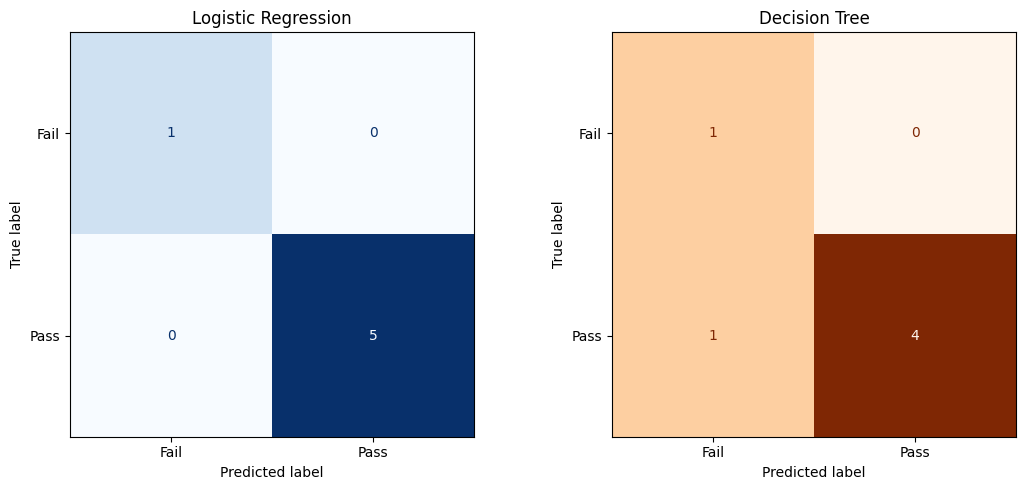

In [11]:
# Visualization 1: Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

cm_log = confusion_matrix(y_test, log_pred)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Fail", "Pass"])
disp_log.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Logistic Regression")

cm_tree = confusion_matrix(y_test, tree_pred)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Fail", "Pass"])
disp_tree.plot(ax=axes[1], cmap="Oranges", values_format="d", colorbar=False)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.savefig("chart1_confusion_matrices.png")
plt.show()

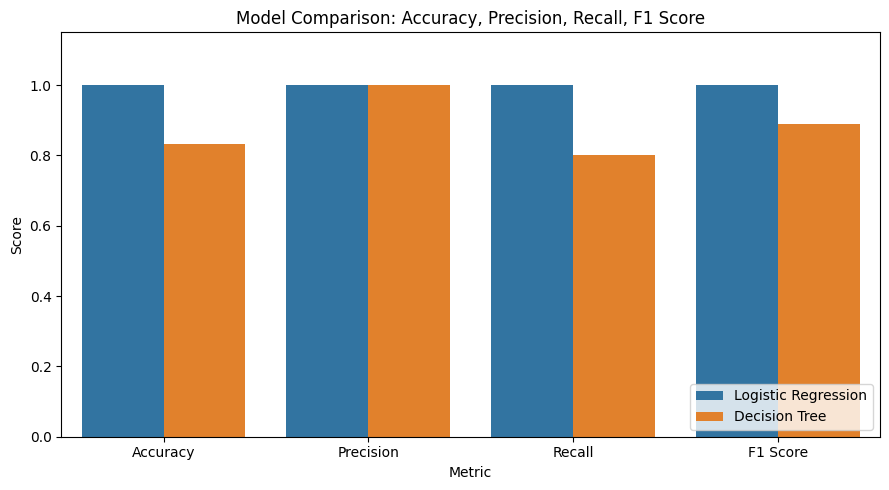

In [12]:
# Visualization 2: Metric comparison bar chart
metrics_melted = comparison_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison: Accuracy, Precision, Recall, F1 Score")
plt.ylim(0, 1.15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("chart2_metric_comparison.png")
plt.show()

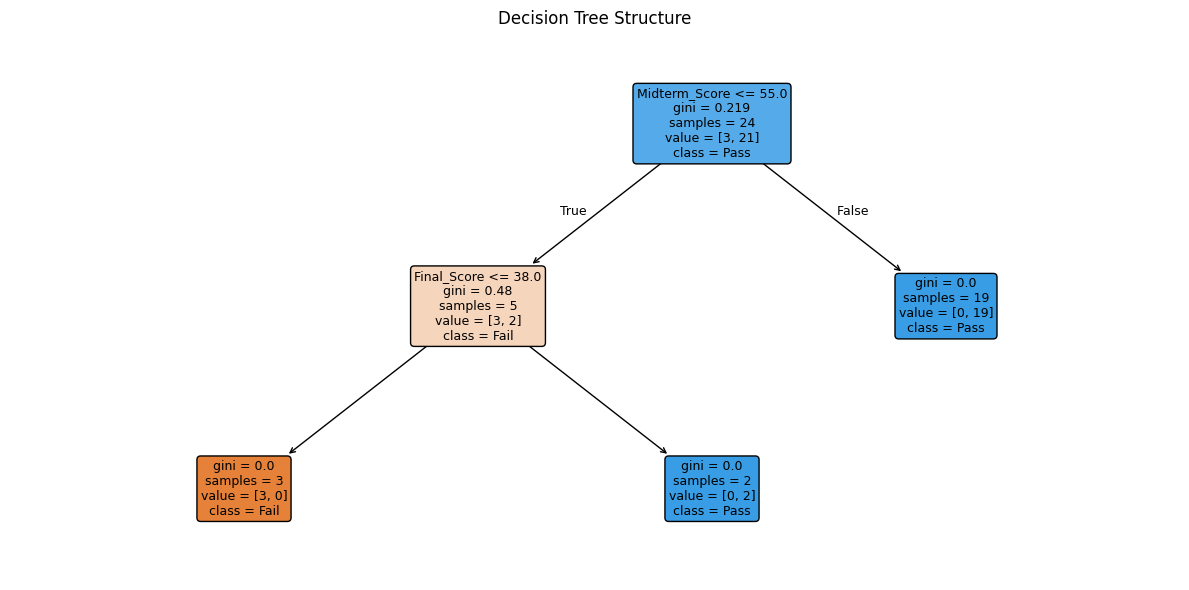

In [13]:
# Visualization 3: The Decision Tree structure itself
# (This helps us see exactly what questions the tree is asking)
plt.figure(figsize=(12, 6))
plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Structure")
plt.tight_layout()
plt.savefig("chart3_decision_tree_structure.png")
plt.show()

## 11. Analysis

**Which model performed better?**

Based on the numbers in our comparison table, Logistic Regression scored
higher on Accuracy, Recall, and F1 Score, and matched the Decision Tree
on Precision. On this test set, Logistic Regression correctly predicted
all 6 students, while the Decision Tree got 5 out of 6 correct — it
predicted "Fail" for one student who had actually Passed.

**Important: we should not just say "Logistic Regression wins" and stop
there.** Looking only at accuracy would hide something useful: the
Decision Tree's Precision was still a perfect 1.0. That means whenever
the Decision Tree did predict "Pass," it was always correct — its single
mistake was being *too cautious* (predicting Fail for an actual Pass
student), not being reckless (it never predicted Pass for an actual Fail
student). This is exactly why Precision and Recall are reported
separately instead of only looking at one combined number.

**Why do we think Logistic Regression performed better (on this test set)?**

- Logistic Regression combines all features smoothly using weights, which
  suits our target well since the target itself (Overall Score) is also a
  weighted combination of the same underlying scores.
- The Decision Tree only used 2 splits and completely ignored Attendance
  and Assignment Score (their importance came out as 0), relying only on
  Midterm and Final Score. With so little training data (24 students),
  the tree had very few examples to learn a more nuanced pattern from,
  so it likely oversimplified.
- That said, this result is based on just **6 test students**. With such
  a small test set, a single student's outcome can easily change which
  model "wins" — this comparison should be read as an illustration of how
  to compare models properly, not as strong proof that Logistic Regression
  is inherently better for this type of problem.

**Was the dataset balanced?**

No. Out of 30 students, 26 Passed and only 4 Failed (about 87% vs 13%).
This is an imbalanced dataset, and it's a big part of why Accuracy alone
can be misleading here — a model could reach roughly 87% accuracy just by
predicting "Pass" for every single student, without learning anything
meaningful. This is exactly why we also looked at Precision, Recall, and
F1 Score, and specifically watched how each model handled the small
number of "Fail" cases.

**What could improve the results?**

- **A larger dataset** — 30 students (and only 6 in the test set) is too
  small to draw strong conclusions from. Hundreds of records would give
  much more reliable and stable comparison results.
- **More balanced classes** — collecting more "Fail" examples (or using
  techniques like oversampling) would make Accuracy a more trustworthy
  metric on its own, and would give both models more to learn from.
- **Cross-validation** instead of a single train/test split, so the
  comparison isn't dependent on which particular 6 students happened to
  land in the test set.
- **More/better features** — additional information (like study hours,
  previous grades, or participation) might help both models separate
  Pass from Fail more reliably than attendance and scores alone.
- **Tuning the Decision Tree** — limiting or adjusting its depth, or
  trying an ensemble method like Random Forest, might reduce the
  oversimplification we saw here.